In [12]:
# This is a hot-fix to use pytorch on Intel Macs -- Credits to Google Gemini

import sys
import types
import PIL.Image
import PIL
import torchvision

# 1. FIX PILLOW (The PILLOW_VERSION error)
PIL.PILLOW_VERSION = PIL.__version__
PIL.Image.PILLOW_VERSION = PIL.__version__

# 2. FIX TORCHVISION IO (The 'cannot import name io' error)
# We create a fake module and attach it to torchvision so the import succeeds
if not hasattr(torchvision, 'io'):
    mock_io = types.ModuleType("io")
    torchvision.io = mock_io
    sys.modules["torchvision.io"] = mock_io
    print("Successfully patched torchvision.io for Intel Mac compatibility.")

# 3. FIX INTERPOLATION (The NEAREST_EXACT/Resampling errors)
class FakeInterpolation:
    NEAREST = 0; BILINEAR = 2; BICUBIC = 3; LANCZOS = 1; HAMMING = 4; BOX = 5
    NEAREST_EXACT = 0; TRIANGLE = 2
if not hasattr(torchvision.transforms, 'InterpolationMode'):
    torchvision.transforms.InterpolationMode = FakeInterpolation

if not hasattr(PIL.Image, 'Resampling'):
    PIL.Image.Resampling = PIL.Image

In [13]:
# Requires transformers>=4.36.0    
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

model_path = 'Alibaba-NLP/gte-base-en-v1.5'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path, trust_remote_code=True)

# Tokenize the input texts
batch_dict = tokenizer(input_texts, max_length=8192, padding=True, truncation=True, return_tensors='pt')

outputs = model(**batch_dict)
embeddings = outputs.last_hidden_state[:, 0]
 
# (Optionally) normalize embeddings
embeddings = F.normalize(embeddings, p=2, dim=1)
scores = (embeddings[:1] @ embeddings[1:].T) * 100
print(scores.tolist())


[[34.504947662353516, 64.03975677490234, 19.5200252532959]]


In [14]:
# Requires sentence_transformers>=2.7.0

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

sentences = ['That is a happy person', 'That is a very happy person']

model = SentenceTransformer('Alibaba-NLP/gte-base-en-v1.5', trust_remote_code=True)
embeddings = model.encode(sentences)
print(cos_sim(embeddings[0], embeddings[1]))


tensor([[0.9606]])


In [ ]:
import json
import sqlite3
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [131]:
# Read in data

''' 
Takes a dataframe and outputs a column where the dates are turned into a numerical representation
where years are integers and days are decimals past that integer.
For missing date entries, NaN is inputted
args:
    data (pd): Dataframe
    column_name (str): key to date column to turn into numerics
returns:
    dates_numeric (pd): Dataframe column of numerics
'''
def dates_to_numerics(data, column_name):
    dates_numeric = pd.to_datetime(data[column_name], errors = 'coerce')
    dates_numeric = dates_numeric.dt.year + (dates_numeric.dt.dayofyear - 1) / 365.25
    #dates_numeric = dates_numeric.fillna(dates_numeric.median())
    return dates_numeric

def one_hot_embedding(data, column_name):
    pass
''' 
Create a dataframe from db file and processes the columns in the following ways:
    - Dates are turned into numerics
args:
    db_path (str): path to db file
    json_path (str): path to json comment file
returns:

'''
def read_data(db_path, json_path, is_train = True):
    train = "_train" if is_train else "_test"
    conn = sqlite3.connect(db_path)
    residents = pd.read_sql_query(f"SELECT * FROM residents{train}", conn)
    maintenance = pd.read_sql_query(f"SELECT * FROM maintenance_history{train}", conn)
    offers = pd.read_sql_query(f"SELECT * FROM renewal_offers{train}", conn)

    return residents, maintenance, offers

residents_raw, maintenance_raw, offers_raw = read_data("research-practical-main/data/resident_database.db", 
    "research-practical-main/data/conversations_train.json", True)

residents = residents_raw.copy()
maintenance = maintenance_raw.copy()
offers = offers_raw.copy()

In [132]:
# --- Begin processing data into readable formats --- #

print(residents.keys())
print(maintenance.keys())
print(offers.keys())

# Begin by analyzing NaN data
print("Checking for NaN Entries")
print(" -- For Resident information")
for col in residents.columns:
    if residents[col].isna().sum() > 0:
        print(f"In column %s there are %d NaN entries" % (col, residents[col].isna().sum()))
print(" -- For Maintenance information")
for col in maintenance.columns:
    if maintenance[col].isna().sum() > 0:
        print(f"In column %s there are %d NaN entries" % (col, maintenance[col].isna().sum()))
print(" -- For Offers information")
for col in offers.columns:
    if offers[col].isna().sum() > 0:
        print(f"In column %s there are %d NaN entries" % (col, offers[col].isna().sum()))


Index(['resident_id', 'name', 'phone_number', 'age', 'parking_space_id',
       'emergency_contact', 'lease_start_date', 'lease_end_date',
       'unit_number', 'pet_details', 'referral', 'call_history',
       'payment_method', 'ADA_support', 'newsletter_opt_in', 'monthly_rent'],
      dtype='object')
Index(['work_order_id', 'date_submitted', 'resident_id', 'issue_type',
       'issue_description', 'priority', 'status', 'assigned_to',
       'target_completion_date', 'date_completed', 'materials_required',
       'submission_method', 'notes', 'unit_number'],
      dtype='object')
Index(['unit', 'rent', 'date_sent', 'sent_by', 'renewal_decision'], dtype='object')
Checking for NaN Entries
 -- For Resident information
In column pet_details there are 406 NaN entries
In column referral there are 159 NaN entries
In column ADA_support there are 714 NaN entries
 -- For Maintenance information
In column date_completed there are 801 NaN entries
 -- For Offers information


In [133]:
print(residents['pet_details'])

0           None
1      2,cat,dog
2           None
3          1,cat
4           None
         ...    
798         None
799        1,dog
800         None
801         None
802        1,dog
Name: pet_details, Length: 803, dtype: object


In [134]:
residents['pet_details'] = residents_raw['pet_details'].str.strip().str[0]
residents['pet_details'] = pd.to_numeric(residents['pet_details'])
residents['pet_details'] = residents['pet_details'].fillna(0)
print(residents['pet_details'])

0      0.0
1      2.0
2      0.0
3      1.0
4      0.0
      ... 
798    0.0
799    1.0
800    0.0
801    0.0
802    1.0
Name: pet_details, Length: 803, dtype: float64


In [135]:
print(residents['referral'])

0                None
1                None
2             walk-in
3            resident
4            facebook
            ...      
798       ex-resident
799            zillow
800       ex-resident
801    apartments.com
802            zillow
Name: referral, Length: 803, dtype: object


In [136]:
def one_hot_embedding(df, col):
    encoder = OneHotEncoder(drop = 'first', sparse_output = False)
    encoded_data = encoder.fit_transform(df[[col]])
    encoded_cols = encoder.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded_data, columns = encoded_cols, index = df.index)

    return pd.concat([df.drop(col, axis = 1), encoded_df], axis = 1)

residents = one_hot_embedding(residents, 'referral')

In [137]:
print(residents.keys())

Index(['resident_id', 'name', 'phone_number', 'age', 'parking_space_id',
       'emergency_contact', 'lease_start_date', 'lease_end_date',
       'unit_number', 'pet_details', 'call_history', 'payment_method',
       'ADA_support', 'newsletter_opt_in', 'monthly_rent',
       'referral_craigslist', 'referral_ex-resident', 'referral_facebook',
       'referral_resident', 'referral_walk-in', 'referral_zillow',
       'referral_None'],
      dtype='object')


In [138]:
residents['ADA_support'] = residents_raw['ADA_support']
print(residents['ADA_support'])

0          None
1          None
2          None
3          None
4         other
         ...   
798        None
799        None
800    mobility
801        None
802        None
Name: ADA_support, Length: 803, dtype: object


In [139]:
residents['ADA_support'] = residents_raw['ADA_support']
residents['ADA_support'] = residents['ADA_support'].notnull().astype(int)
print(residents['ADA_support'])

0      0
1      0
2      0
3      0
4      1
      ..
798    0
799    0
800    1
801    0
802    0
Name: ADA_support, Length: 803, dtype: int64


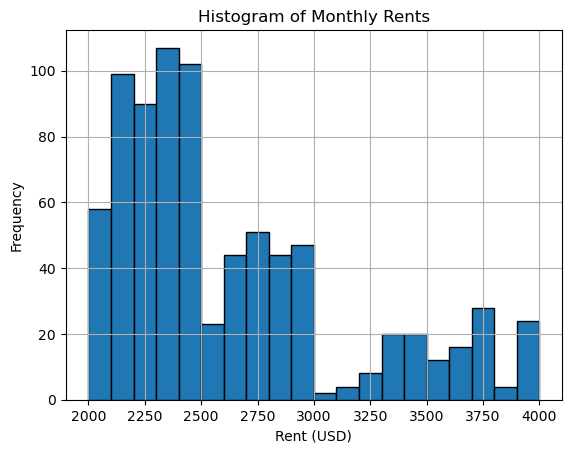

In [140]:
import matplotlib.pyplot as plt
residents['monthly_rent'].hist(bins=20, edgecolor='black')
plt.title('Histogram of Monthly Rents')
plt.xlabel('Rent (USD)')
plt.ylabel('Frequency')
plt.show()

In [141]:
print(maintenance.keys())

Index(['work_order_id', 'date_submitted', 'resident_id', 'issue_type',
       'issue_description', 'priority', 'status', 'assigned_to',
       'target_completion_date', 'date_completed', 'materials_required',
       'submission_method', 'notes', 'unit_number'],
      dtype='object')


In [165]:
#print(maintenance['resident_id'])
print(maintenance[maintenance['resident_id'] == 10981].head())

      work_order_id  date_submitted  resident_id  issue_type  \
1639           4025     2025.301164        10981        HVAC   
1640           4026     2024.856947        10981    plumbing   
1641           4027     2024.038330        10981  electrical   
1642           4028     2023.878850        10981        HVAC   
1643           4029     2024.386037        10981   furniture   

                 issue_description priority       status assigned_to  \
1639     Thermostat malfunctioning   medium      on hold         Jim   
1640  Low water pressure in shower     high    completed         Jim   
1641      Power outlet not working      low    submitted         Jim   
1642                AC not cooling     high    completed         Jim   
1643   Broken chair in dining area      low  in progress         Jim   

      target_completion_date  date_completed    materials_required  \
1639             2025.306639             NaN                  None   
1640             2024.884326     2024.8678

In [149]:
# 1. Turn dates into numerics
dates_res = ['lease_start_date', 'lease_end_date']
dates_maint = ['date_submitted', 'target_completion_date', 'date_completed']
dates_offers = ['date_sent']

for col in dates_res:
    residents[col] = dates_to_numerics(residents, col)
for col in dates_maint:
    maintenance[col] = dates_to_numerics(maintenance, col)
for col in dates_offers:
    offers[col] = dates_to_numerics(offers, col)

In [155]:
#print(residents[residents['unit_number'] == 218])
print(residents_raw.iloc[443, :])

resident_id                                            10552
name                                             Mike Torres
phone_number                                    263-950-4641
age                                                       33
parking_space_id                                           1
emergency_contact         Quinn Nguyen, 514-591-7370, Spouse
lease_start_date                         2024-02-01 00:00:00
lease_end_date                           2025-01-31 23:59:00
unit_number                                              218
pet_details                                             None
referral                                              zillow
call_history         2025-05-05 02:02:17,2024-08-27 21:27:17
payment_method                                         check
ADA_support                                             None
newsletter_opt_in                                          1
monthly_rent                                            2639
Name: 443, dtype: object

In [ ]:
maintenance['completion_time'] = maintenance['target_completion_date'] - maintenance['date_submitted']
maintenance['completion_diff'] = maintenance['target_completion_date'] - maintenance['date_completed']
maintenance['is_completed'] = (maintenance['status'] == 'completed').astype(int)


   work_order_id  date_submitted  resident_id  issue_type  \
0           2001     2024.950034        10000  electrical   
1           2002     2024.761123        10552   furniture   
2           2003     2025.008214        10552    plumbing   
3           2004     2024.807666        10552        pest   
4           2005     2023.583162        10001   furniture   

              issue_description priority       status assigned_to  \
0    Ceiling fan not turning on      low  in progress         Jim   
1   Broken chair in dining area   medium    completed         Jim   
2  Low water pressure in shower   medium    completed        John   
3           Bed bugs in bedroom     high    completed       James   
4   Broken chair in dining area      low    completed        John   

   target_completion_date  date_completed materials_required  \
0             2024.955510             NaN       Outlet cover   
1             2024.788501     2024.761123        Wood screws   
2             2025.035592 

In [248]:
maintenance_agg = maintenance.groupby(['resident_id']).agg(
    tot_completion_time = ('completion_time', 'sum'),
    tot_completion_diff = ('completion_diff', 'sum'),
    number_of_requests = ('resident_id', 'size'),
    number_of_completed_requests = ('is_completed', 'sum')).reset_index()

#maintenance_agg['percentage_completed'] = (maintenance_agg['number_of_completed_requests'] / maintenance_agg['number_of_requests'])
maintenance_agg['tot_completion_diff'] = maintenance_agg['tot_completion_diff'].fillna(maintenance_agg['tot_completion_diff'].median())
maintenance_agg['tot_completion_time'] = maintenance_agg['tot_completion_time'].fillna(maintenance_agg['tot_completion_time'].median())
print(maintenance_agg.head())

   resident_id  tot_completion_time  tot_completion_diff  number_of_requests  \
0        10000             0.005476             0.000000                   1   
1        10001             0.076660             0.057495                   4   
2        10002             0.010951             0.000000                   1   
3        10003             0.002738            -0.002738                   1   
4        10005             0.073922             0.021903                   4   

   number_of_completed_requests  
0                             0  
1                             4  
2                             0  
3                             1  
4                             3  


In [249]:
aggregated_data = residents.merge(maintenance_agg, on = 'resident_id', how = 'left')
#aggregated_data['avg_completion_diff'] = aggregated_data['avg_completion_diff'].fillna(0)
#aggregated_data['avg_completion_time'] = aggregated_data['avg_completion_time'].fillna(0)
#aggregated_data['percentage_completed'] = aggregated_data['percentage_completed'].fillna(1)
#aggregated_data['number_of_requests'] = aggregated_data['number_of_requests'].fillna(0)

In [285]:
print(offers.head())

   unit  rent    date_sent           sent_by  renewal_decision
0   218  2957  2025.199863     Leasing Agent                 0
1   111  2934  2025.301164  Property Manager                 0
2   168  3360  2025.323066     Leasing Agent                 0
3   202  3511  2025.281999     Leasing Agent                 1
4   528  2671  2025.284736    Leasing Office                 0


In [192]:
print(offers['unit'].is_unique)

True


In [250]:
aggregated_data = aggregated_data.merge(offers, left_on = 'unit_number', right_on = 'unit')

In [251]:
print(aggregated_data[aggregated_data['unit_number'] == 111])

     resident_id            name  phone_number  age  parking_space_id  \
1          10001     Julia Allen  246-510-1838   25                24   
333        10406    Gina Stewart  530-948-5646   36                23   
549        10679  Charlie Nelson  629-215-7790   36                 8   

                         emergency_contact  lease_start_date  lease_end_date  \
1     Gina Mitchell, 466-435-7101, Partner       2022.832307     2023.829569   
333       Bob Martin, 402-359-7689, Friend       2022.832307     2023.829569   
549  Sophie Phillips, 373-157-3481, Mother       2022.832307     2023.829569   

     unit_number  pet_details  ... referral_None tot_completion_time  \
1            111          2.0  ...           1.0            0.076660   
333          111          0.0  ...           1.0            0.046543   
549          111          1.0  ...           0.0            0.024641   

     tot_completion_diff  number_of_requests  number_of_completed_requests  \
1               0.0

In [252]:
print(aggregated_data.keys())
aggregated_data[aggregated_data['unit_number'] == 218]['newsletter_opt_in']

Index(['resident_id', 'name', 'phone_number', 'age', 'parking_space_id',
       'emergency_contact', 'lease_start_date', 'lease_end_date',
       'unit_number', 'pet_details', 'call_history', 'payment_method',
       'ADA_support', 'newsletter_opt_in', 'monthly_rent',
       'referral_craigslist', 'referral_ex-resident', 'referral_facebook',
       'referral_resident', 'referral_walk-in', 'referral_zillow',
       'referral_None', 'tot_completion_time', 'tot_completion_diff',
       'number_of_requests', 'number_of_completed_requests', 'unit', 'rent',
       'date_sent', 'sent_by', 'renewal_decision'],
      dtype='object')


0      0
443    1
Name: newsletter_opt_in, dtype: int64

In [286]:
agg_rules = {
    'age' : 'mean',
    'lease_start_date' : 'first',
    'lease_end_date' : 'first',
    'pet_details' : 'max',
    'ADA_support' : 'first',
    'newsletter_opt_in' : 'sum',
    'monthly_rent' : 'first',
    'referral_craigslist' : 'sum',
    'referral_ex-resident' : 'sum',
    'referral_facebook' : 'sum',
    'referral_resident' : 'sum',
    'referral_walk-in' : 'sum',
    'referral_zillow' : 'sum',
    'referral_None' : 'sum',
    'tot_completion_time' : 'sum',
    'tot_completion_diff' : 'sum',
    'number_of_requests' : 'sum',
    'number_of_completed_requests' : 'sum',
    'occupancy_count' : 'first',
    'rent' : 'first',
    'renewal_decision' : 'first'
}

In [254]:
aggregated_data['lease_end_as_date'] = residents['lease_end_date']
aggregated_data['number_of_requests'] = aggregated_data['number_of_requests'].fillna(0)
aggregated_data['number_of_completed_requests'] = aggregated_data['number_of_completed_requests'].fillna(0)


In [255]:
aggregated_data['occupancy_count'] = aggregated_data.groupby(['unit_number', 'lease_end_as_date'])['unit_number'].transform('size')
aggregated_data[aggregated_data['unit_number'] == 111].head()

,resident_id,name,phone_number,age,parking_space_id,emergency_contact,lease_start_date,lease_end_date,unit_number,pet_details,...,tot_completion_diff,number_of_requests,number_of_completed_requests,unit,rent,date_sent,sent_by,renewal_decision,lease_end_as_date,occupancy_count
1,10001,Julia Allen,246-510-1838,25,24,"Gina Mitchell, 466-435-7101, Partner",2022.832307,2023.829569,111,2.0,...,0.057495,4.0,4.0,111,2934,2025.301164,Property Manager,0,2023.829569,3
333,10406,Gina Stewart,530-948-5646,36,23,"Bob Martin, 402-359-7689, Friend",2022.832307,2023.829569,111,0.0,...,0.021903,3.0,2.0,111,2934,2025.301164,Property Manager,0,2023.829569,3
549,10679,Charlie Nelson,629-215-7790,36,8,"Sophie Phillips, 373-157-3481, Mother",2022.832307,2023.829569,111,1.0,...,0.000000,1.0,0.0,111,2934,2025.301164,Property Manager,0,2023.829569,3


In [287]:
final_data = aggregated_data.groupby(['unit_number', 'lease_end_as_date'], as_index = False).agg(agg_rules)

In [288]:
final_data

,unit_number,lease_end_as_date,age,lease_start_date,lease_end_date,pet_details,ADA_support,newsletter_opt_in,monthly_rent,referral_craigslist,...,referral_walk-in,referral_zillow,referral_None,tot_completion_time,tot_completion_diff,number_of_requests,number_of_completed_requests,occupancy_count,rent,renewal_decision
0,1,2024.495551,28.5,2023.495551,2024.495551,1.0,1,0,2137,0.0,...,0.0,0.0,0.0,0.071869,0.000000,4.0,0.0,2,2350,0
1,2,2025.082136,34.0,2024.583162,2025.082136,0.0,0,0,2383,0.0,...,1.0,0.0,0.0,0.068446,0.043806,3.0,2.0,1,2508,1
2,4,2023.577687,25.0,2022.580424,2023.577687,1.0,0,1,2194,0.0,...,0.0,0.0,0.0,0.043806,0.008214,4.0,3.0,1,2425,0
3,5,2025.158795,27.5,2024.164271,2025.158795,0.0,1,1,2497,1.0,...,0.0,0.0,1.0,0.043806,0.002738,3.0,1.0,2,2868,0
4,6,2024.580424,29.0,2023.580424,2024.580424,1.0,0,1,2353,0.0,...,0.0,0.0,0.0,0.104038,0.030116,7.0,3.0,2,2751,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,560,2024.246407,23.0,2023.246407,2024.246407,0.0,0,1,2399,0.0,...,1.0,0.0,0.0,0.038330,0.027379,2.0,2.0,1,2666,1
450,563,2025.243669,24.0,2024.750171,2025.243669,1.0,0,1,2664,0.0,...,1.0,0.0,1.0,0.076660,-0.002738,7.0,3.0,2,2959,0
451,566,2025.082136,36.5,2024.084873,2025.082136,0.0,0,2,2956,0.0,...,0.0,0.0,0.0,0.071184,0.000000,4.0,0.0,2,3177,1
452,567,2025.243669,36.0,2023.246407,2025.243669,0.0,0,1,2298,0.0,...,0.0,0.0,0.0,0.128679,0.030116,6.0,3.0,1,2689,1


In [317]:
final_data['avg_completion_time'] = final_data['tot_completion_time'] / final_data['number_of_completed_requests']
final_data['avg_completion_diff'] = final_data['tot_completion_diff'] / final_data['number_of_completed_requests']
final_data['percent_completion'] = final_data['number_of_completed_requests'] / final_data['number_of_requests']
final_data['rent_diff'] = final_data['rent'] - final_data['monthly_rent']
final_data['percent_rent_diff'] = final_data['rent_diff'] / final_data['monthly_rent']
final_data['lease_length'] = final_data['lease_end_date'] - final_data['lease_start_date']

In [305]:
final_data.keys()
final_data

,unit_number,lease_end_as_date,age,lease_start_date,lease_end_date,pet_details,ADA_support,newsletter_opt_in,monthly_rent,referral_craigslist,...,number_of_completed_requests,occupancy_count,rent,renewal_decision,avg_completion_time,avg_completion_diff,percent_completion,rent_diff,percent_rent_diff,lease_length
0,1,2024.495551,28.5,2023.495551,2024.495551,1.0,1,0,2137,0.0,...,0.0,2,2350,0,0.017967,0.000000,0.000000,213,0.099672,1.000000
1,2,2025.082136,34.0,2024.583162,2025.082136,0.0,0,0,2383,0.0,...,2.0,1,2508,1,0.022815,0.014602,0.666667,125,0.052455,0.498973
2,4,2023.577687,25.0,2022.580424,2023.577687,1.0,0,1,2194,0.0,...,3.0,1,2425,0,0.010951,0.002053,0.750000,231,0.105287,0.997262
3,5,2025.158795,27.5,2024.164271,2025.158795,0.0,1,1,2497,1.0,...,1.0,2,2868,0,0.014602,0.000913,0.333333,371,0.148578,0.994524
4,6,2024.580424,29.0,2023.580424,2024.580424,1.0,0,1,2353,0.0,...,3.0,2,2751,0,0.014863,0.004302,0.428571,398,0.169146,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,560,2024.246407,23.0,2023.246407,2024.246407,0.0,0,1,2399,0.0,...,2.0,1,2666,1,0.019165,0.013689,1.000000,267,0.111296,1.000000
450,563,2025.243669,24.0,2024.750171,2025.243669,1.0,0,1,2664,0.0,...,3.0,2,2959,0,0.010951,-0.000391,0.428571,295,0.110736,0.493498
451,566,2025.082136,36.5,2024.084873,2025.082136,0.0,0,2,2956,0.0,...,0.0,2,3177,1,0.017796,0.000000,0.000000,221,0.074763,0.997262
452,567,2025.243669,36.0,2023.246407,2025.243669,0.0,0,1,2298,0.0,...,3.0,1,2689,1,0.021446,0.005019,0.500000,391,0.170148,1.997262


In [293]:
print(f"Total number of units with 100% completion rates: {(final_data['percent_completion'] > 0.99).sum()}")

Total number of units with 100% completion rates: 69


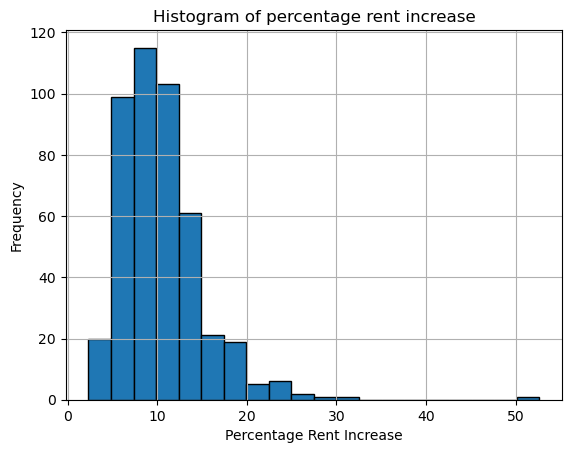

In [ ]:
plt.clf()

(final_data['percent_rent_diff'] * 100).hist(bins=20, edgecolor='black')
plt.title('Histogram of percentage rent increase')
plt.xlabel('Percentage Rent Increase')
plt.ylabel('Frequency')
plt.show()

In [297]:
final_data[final_data['percent_rent_diff'] > 0.4]

,unit_number,lease_end_as_date,age,lease_start_date,lease_end_date,pet_details,ADA_support,newsletter_opt_in,monthly_rent,referral_craigslist,...,number_of_requests,number_of_completed_requests,occupancy_count,rent,renewal_decision,avg_completion_time,avg_completion_diff,percent_completion,rent_diff,percent_rent_diff
411,508,2024.580424,39.0,2024.084873,2024.580424,0.0,0,1,2406,0.0,...,2.0,0.0,1,3673,1,0.010951,0.0,0.0,1267,0.5266


In [298]:
# Outlier checks, using winsorization to clean up data and IQR
import numpy as np

def winsorization_iqr(series, thr = 1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = 1.5 * IQR + Q3
    lower_bound = Q1 - 1.5 * IQR
    return np.clip(series, lower_bound, upper_bound) 

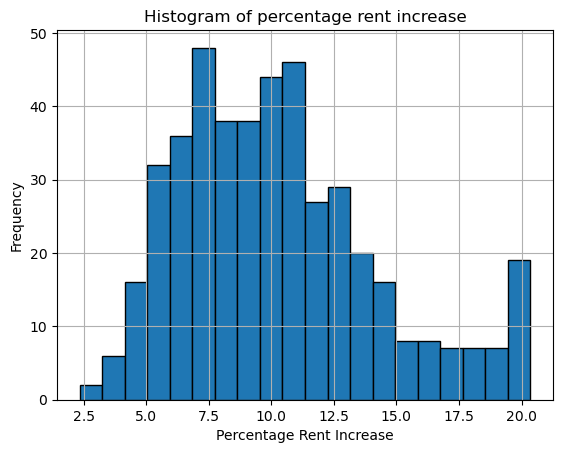

In [ ]:
final_data['percent_rent_diff'] = winsorization_iqr(final_data['percent_rent_diff'])
(final_data['percent_rent_diff'] * 100).hist(bins=20, edgecolor='black')
plt.title('Histogram of percentage rent increase')
plt.xlabel('Percentage Rent Increase')
plt.ylabel('Frequency')
plt.show()

In [300]:
final_data[final_data['percent_rent_diff'] > 0.2]

,unit_number,lease_end_as_date,age,lease_start_date,lease_end_date,pet_details,ADA_support,newsletter_opt_in,monthly_rent,referral_craigslist,...,number_of_requests,number_of_completed_requests,occupancy_count,rent,renewal_decision,avg_completion_time,avg_completion_diff,percent_completion,rent_diff,percent_rent_diff
12,18,2024.665298,29.50,2023.665298,2024.665298,0.0,0,1,2755,0.0,...,1.0,0.0,2,3443,1,0.008214,0.000000,0.000000,688,0.203583
36,44,2024.413415,33.00,2023.413415,2024.413415,0.0,0,0,2077,0.0,...,2.0,1.0,1,2500,1,0.020534,0.008214,0.500000,423,0.203583
72,97,2024.832307,27.75,2023.832307,2024.832307,1.0,0,3,3927,0.0,...,1.0,1.0,4,5050,1,0.027379,0.024641,1.000000,1123,0.203583
106,137,2023.662560,32.00,2022.665298,2023.662560,1.0,0,0,2175,0.0,...,6.0,2.0,1,2704,0,0.019165,0.005932,0.333333,529,0.203583
162,212,2023.829569,24.00,2022.832307,2023.829569,1.0,0,1,2180,0.0,...,3.0,0.0,2,2681,0,0.011864,0.000000,0.000000,501,0.203583
197,254,2024.161533,24.00,2023.161533,2024.161533,2.0,0,1,2213,0.0,...,1.0,1.0,1,2806,1,0.016427,0.002738,1.000000,593,0.203583
214,277,2025.325804,39.00,2023.832307,2025.325804,1.0,0,0,2252,0.0,...,5.0,2.0,1,2795,1,0.017522,0.005476,0.400000,543,0.203583
222,288,2023.996578,21.00,2023.000000,2023.996578,1.0,0,1,2484,0.0,...,4.0,1.0,1,3079,0,0.008214,0.002738,0.250000,595,0.203583
288,360,2024.495551,25.00,2023.495551,2024.495551,0.0,0,1,2316,0.0,...,5.0,2.0,1,2830,0,0.018070,-0.000548,0.400000,514,0.203583
324,402,2024.665298,31.00,2022.665298,2024.665298,1.0,0,1,2136,0.0,...,3.0,1.0,1,2667,1,0.024869,0.005476,0.333333,531,0.203583


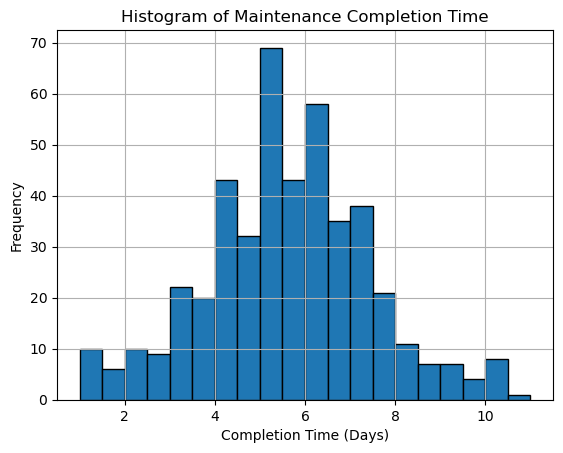

In [301]:
(final_data['avg_completion_time'] * 365.25).hist(bins=20, edgecolor='black')
plt.title('Histogram of Maintenance Completion Time')
plt.xlabel('Completion Time (Days)')
plt.ylabel('Frequency')
plt.show()

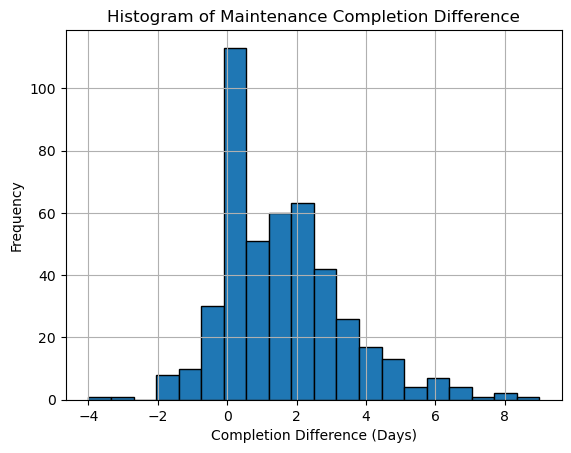

In [303]:
(final_data['avg_completion_diff'] * 365.25).hist(bins=20, edgecolor='black')
plt.title('Histogram of Maintenance Completion Difference')
plt.xlabel('Completion Difference (Days)')
plt.ylabel('Frequency')
plt.show()

In [306]:
final_data['occupancy_count'].value_counts()

occupancy_count
1    220
2    164
4     45
3     25
Name: count, dtype: int64

In [307]:
final_data['pet_details'].value_counts()

pet_details
1.0    213
0.0    154
2.0     87
Name: count, dtype: int64

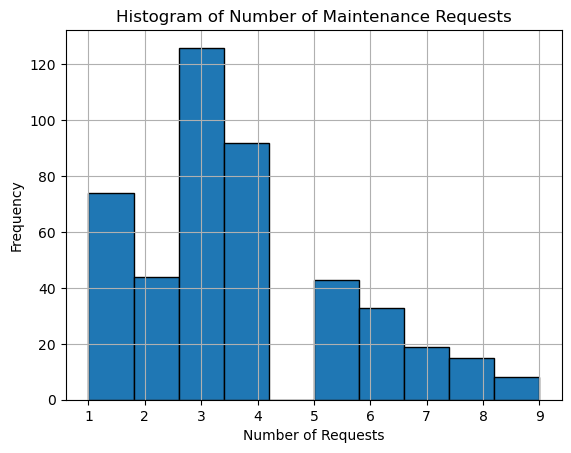

In [313]:
(final_data['number_of_requests']).hist(bins=10, edgecolor='black')
plt.title('Histogram of Number of Maintenance Requests')
plt.xlabel('Number of Requests')
plt.ylabel('Frequency')
plt.show()

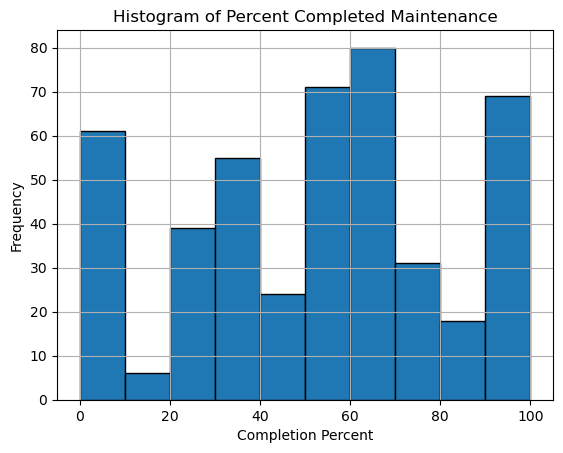

In [312]:
(final_data['percent_completion'] * 100).hist(bins=10, edgecolor='black')
plt.title('Histogram of Percent Completed Maintenance')
plt.xlabel('Completion Percent')
plt.ylabel('Frequency')
plt.show()

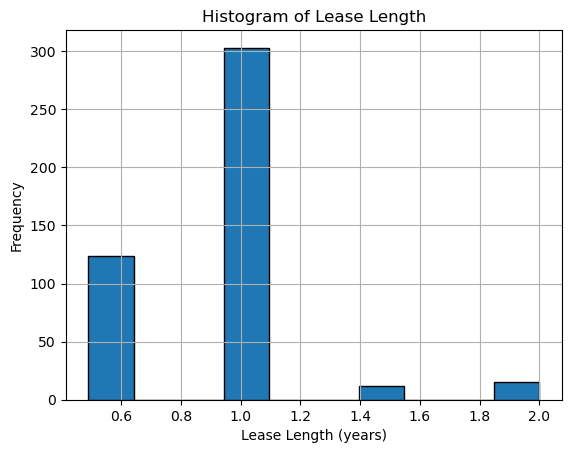

In [316]:
(final_data['lease_length']).hist(bins=10, edgecolor='black')
plt.title('Histogram of Lease Length')
plt.xlabel('Lease Length (years)')
plt.ylabel('Frequency')
plt.show()